In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [2]:
pdf = pd.read_csv('patients.csv')
patients = pd.DataFrame(pdf)

patients.iloc[50:61]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
50,Dylan Mcknight,47,Male,B-,Cancer,2019-06-14,Ashley Edwards,"Johnson, Brewer and Hudson",Medicare,10705.098400,437,Emergency,2019-07-13,Penicillin,Inconclusive
51,Olivia Ayala,60,Male,A-,Arthritis,2022-11-26,Leon Price,Cook-Wright,Blue Cross,49576.874033,132,Elective,2022-12-08,Penicillin,Abnormal
52,Frank Mccormick,70,Male,A+,Obesity,2023-08-25,Kyle Estrada,Herrera-Wilson,Blue Cross,8005.828337,271,Urgent,2023-09-12,Ibuprofen,Inconclusive
53,Rachael Davidson,57,Female,O-,Cancer,2022-03-29,Jared Harmon,Moyer-Vasquez,Cigna,41295.399748,361,Emergency,2022-04-02,Aspirin,Normal
54,Lori Owens,19,Male,A+,Arthritis,2021-07-04,Adrian Pierce,Diaz-Ferguson,Blue Cross,20080.297645,303,Emergency,2021-07-29,Ibuprofen,Normal
55,Frank Reid,61,Female,AB+,Obesity,2019-11-04,Jesus Snyder,"Nichols, Stone and Mills",Blue Cross,1888.002111,317,Emergency,2019-11-19,Penicillin,Inconclusive
56,Cynthia Stanton,21,Male,A+,Cancer,2021-12-28,Sara Watts,"Gray, Andersen and Williams",Cigna,44935.269697,439,Emergency,2022-01-09,Lipitor,Abnormal
57,Nicole Williams,82,Male,O-,Hypertension,2022-10-27,Stacy Brewer,Hernandez and Sons,Cigna,10724.033247,153,Urgent,2022-11-18,Aspirin,Normal
58,Michael Miller,61,Male,A+,Diabetes,2023-04-06,Nicholas Aguirre,Lambert and Sons,Blue Cross,14691.250042,438,Elective,2023-04-22,Penicillin,Inconclusive
59,Kenneth Lopez,27,Female,A-,Cancer,2020-01-19,Miranda Robinson,"Wood, Howard and Reed",Cigna,47508.000179,120,Urgent,2020-01-24,Ibuprofen,Inconclusive


In [3]:
print(f"Number of rows: {patients.shape[0]}")
print(f"Number of columns: {patients.shape[1]}")

Number of rows: 10000
Number of columns: 15


In [4]:
patients.nunique()

Name                   9378
Age                      68
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1815
Doctor                 9416
Hospital               8639
Insurance Provider        5
Billing Amount        10000
Room Number             400
Admission Type            3
Discharge Date         1834
Medication                5
Test Results              3
dtype: int64

In [5]:
patients.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [6]:
#Calculate the probability of a male patient with A+ blood to have a Diabetes
# medical condition. Print your answer as a percentage rounded to one decimal. 

filtered_males = patients[ (patients.Gender =='Male') & (patients['Blood Type'] == 'A+')]
male_diabetes = filtered_males[filtered_males['Medical Condition'] =='Diabetes']

percentage = (len(male_diabetes) / len(filtered_males)) * 100

print(f"The percentage is: {round(percentage,1)}% ")

The percentage is: 15.7% 


In [7]:
#2.4 Which blood type is the rarest among all the patients?

patients['Blood Type'].value_counts()

Blood Type
AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: count, dtype: int64

The rarest blood type A-

In [8]:
# 1. Count the occurrences of each blood type
blood_type_counts = patients['Blood Type'].value_counts()

# 2. Find the blood type with the minimum count
rarest_blood_type = blood_type_counts.idxmin()
rarest_count = blood_type_counts.min()

# 3. Print the final answer
print(f"The rarest blood type is {rarest_blood_type} with only {rarest_count} patients.")

The rarest blood type is A- with only 1238 patients.


In [9]:
#What is the name of the patient who received the largest bill for a single
#admission-discharge period?

patients[patients['Billing Amount'] == max(patients['Billing Amount'])]['Name']

8789    Daniel Hall
Name: Name, dtype: str

In [10]:
# 1. Locate the row with the maximum billing amount
largest_bill_row = patients.loc[patients['Billing Amount'].idxmax()]

# 2. Extract the patient's name and the bill amount
patient_name = largest_bill_row['Name']
bill_amount = largest_bill_row['Billing Amount']

# 3. Print the final answer
print(f"The patient with the largest bill is {patient_name} with an amount of {bill_amount:,.2f}")

The patient with the largest bill is Daniel Hall with an amount of 49,995.90


In [11]:
#2.6 On which dates were the most patients admitted to any of the hospitals? 
patients['Date of Admission'].value_counts()

Date of Admission
2019-04-12    15
2022-04-27    15
2021-10-23    14
2022-06-14    14
2022-09-23    14
              ..
2021-02-26     1
2020-08-11     1
2020-09-20     1
2023-03-05     1
2020-07-03     1
Name: count, Length: 1815, dtype: int64

The dates are 2019-04-12 and 2022-04-27

In [12]:
# 1. Count how many patients were admitted on each date
admission_counts = patients['Date of Admission'].value_counts()

# 2. Find the highest number of admissions recorded on a single day
max_admissions = admission_counts.max()

# 3. Retrieve all dates that match this maximum number (to handle potential ties)
most_busy_dates = admission_counts[admission_counts == max_admissions].index.tolist()

# 4. Print the final results
print(f"The date(s) with the most admissions: {most_busy_dates} ({max_admissions} patients admitted)")

The date(s) with the most admissions: ['2019-04-12', '2022-04-27'] (15 patients admitted)


In [13]:
patients.describe(include ='all')

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
count,10000,10000.000000,10000,10000,10000,10000,10000,10000,10000,10000.000000,10000.000000,10000,10000,10000,10000
unique,9378,NaN,2,8,6,1815,9416,8639,5,NaN,NaN,3,1834,5,3
top,Michael Johnson,NaN,Female,AB-,Asthma,2019-04-12,Michael Johnson,Smith PLC,Cigna,NaN,NaN,Urgent,2021-11-28,Penicillin,Abnormal
freq,7,NaN,5075,1275,1708,15,7,19,2040,NaN,NaN,3391,14,2079,3456
mean,NaN,51.452200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25516.806778,300.082000,NaN,NaN,NaN,NaN
std,NaN,19.588974,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14067.292709,115.806027,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000.180837,101.000000,NaN,NaN,NaN,NaN
25%,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13506.523967,199.000000,NaN,NaN,NaN,NaN
50%,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25258.112566,299.000000,NaN,NaN,NaN,NaN
75%,NaN,68.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37733.913727,400.000000,NaN,NaN,NaN,NaN


In [14]:
corr = patients.apply(lambda x: x.factorize()[0]).corr()
corr

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
Name,1.000000,0.006784,-0.006635,0.006116,-0.011538,0.232177,0.885388,0.785205,-0.020325,0.935417,0.039286,-0.005867,0.223371,0.006645,-0.011169
Age,0.006784,1.000000,-0.010447,-0.001023,0.007478,0.011936,0.005097,0.006948,0.018674,0.010923,0.020394,0.012957,-0.000018,0.003178,0.015115
Gender,-0.006635,-0.010447,1.000000,-0.018187,0.000627,0.004993,-0.012439,-0.005863,0.030543,-0.006570,-0.002153,-0.004515,-0.008179,-0.000111,0.017273
Blood Type,0.006116,-0.001023,-0.018187,1.000000,-0.005727,0.008260,0.012226,0.000437,0.022191,0.006790,-0.003818,0.000778,-0.003793,0.006672,-0.004024
Medical Condition,-0.011538,0.007478,0.000627,-0.005727,1.000000,-0.014976,-0.011310,-0.010850,-0.009300,-0.011969,-0.011661,0.005659,0.006807,0.023598,0.000446
Date of Admission,0.232177,0.011936,0.004993,0.008260,-0.014976,1.000000,0.226938,0.211469,-0.014087,0.234464,0.053187,0.005879,0.159833,-0.006039,-0.003426
Doctor,0.885388,0.005097,-0.012439,0.012226,-0.011310,0.226938,1.000000,0.796829,-0.022121,0.945144,0.043933,-0.007760,0.224493,0.009226,-0.005332
Hospital,0.785205,0.006948,-0.005863,0.000437,-0.010850,0.211469,0.796829,1.000000,-0.013523,0.840962,0.052032,0.000688,0.203593,0.019901,-0.007382
Insurance Provider,-0.020325,0.018674,0.030543,0.022191,-0.009300,-0.014087,-0.022121,-0.013523,1.000000,-0.020653,-0.005388,-0.004369,-0.015198,0.023239,0.002515
Billing Amount,0.935417,0.010923,-0.006570,0.006790,-0.011969,0.234464,0.945144,0.840962,-0.020653,1.000000,0.042887,-0.006270,0.232780,0.009739,-0.006269


Text(0.5, 1.0, 'Correlation Heatmap')

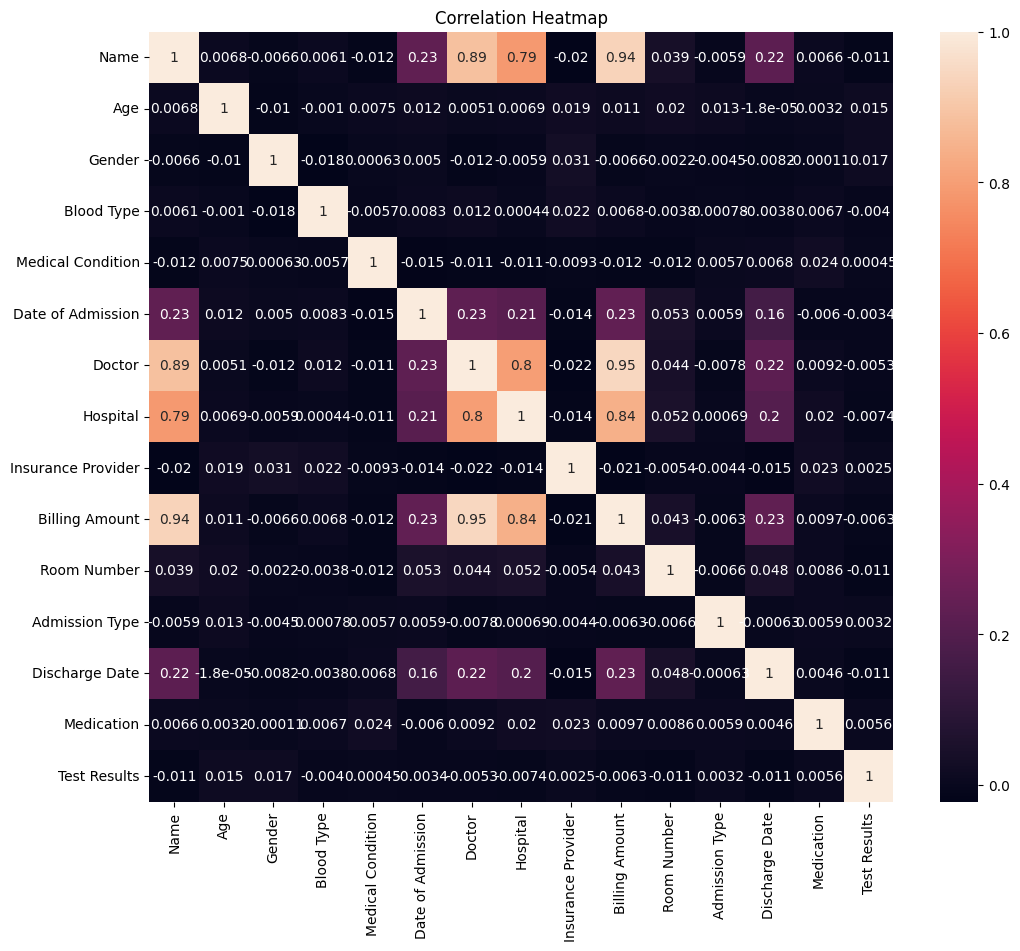

In [15]:
plt.figure(figsize=(12,10))
heat = sns.heatmap(data=corr, annot=True)
plt.title('Correlation Heatmap')

In [16]:
#The Test Result column contains the outcome of tests that were performed on
#the relevant patients. Determine and display the number of records for the
#different test results

patients['Test Results'].value_counts()

Test Results
Abnormal        3456
Inconclusive    3277
Normal          3267
Name: count, dtype: int64

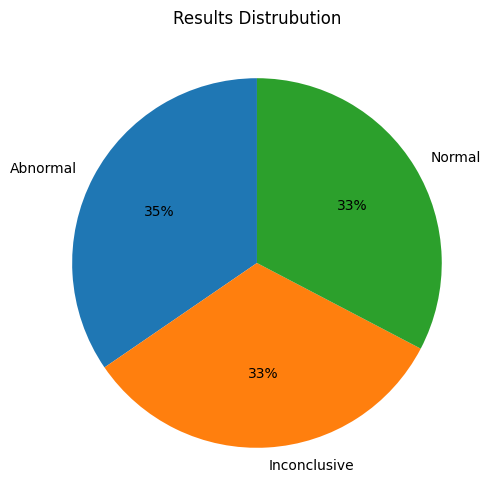

In [17]:
results_count =patients['Test Results'].value_counts()

plt.pie(results_count.to_list(), labels = results_count.index, autopct = '%.0f%%', startangle=90)
plt.title('Results Distrubution')
fig = plt.gcf()
fig.set_size_inches(6, 6)

In [18]:
print("--- 2.7 Class Balancing Recommendation & Discussion ---")
print("Recommendation: The dataset should NOT be balanced.")
print("\nDiscussion:")
print("According to the generated pie chart, the test result outcomes are already ")
print("exceptionally well-distributed: Abnormal makes up 35%, while Normal and ")
print("Inconclusive stand evenly at 33% each. Because the variation between the ")
print("majority and minority classes is a negligible 2%, this data is functionally ")
print("balanced. Artificially forcing a 100% equal representation (33.33% each) via ")
print("oversampling would introduce unneeded synthetic bias, while undersampling ")
print("would risk losing valuable authentic patient records. The current natural ")
print("distribution is ideal for training a reliable model.")

--- 2.7 Class Balancing Recommendation & Discussion ---
Recommendation: The dataset should NOT be balanced.

Discussion:
According to the generated pie chart, the test result outcomes are already 
exceptionally well-distributed: Abnormal makes up 35%, while Normal and 
Inconclusive stand evenly at 33% each. Because the variation between the 
majority and minority classes is a negligible 2%, this data is functionally 
balanced. Artificially forcing a 100% equal representation (33.33% each) via 
oversampling would introduce unneeded synthetic bias, while undersampling 
would risk losing valuable authentic patient records. The current natural 
distribution is ideal for training a reliable model.


In [19]:
patients_reduced = pd.DataFrame(patients)

for feature in patients_reduced.columns:
    if (patients_reduced[feature].nunique() > 10):
       patients_reduced.drop([feature], axis = 1, inplace = True)
        
patients_reduced.head(10)

,Gender,Blood Type,Medical Condition,Insurance Provider,Admission Type,Medication,Test Results
0,Female,O-,Diabetes,Medicare,Elective,Aspirin,Inconclusive
1,Male,O+,Asthma,UnitedHealthcare,Emergency,Lipitor,Normal
2,Male,B-,Obesity,Medicare,Emergency,Lipitor,Normal
3,Male,B-,Asthma,Medicare,Urgent,Penicillin,Abnormal
4,Male,O-,Arthritis,UnitedHealthcare,Urgent,Paracetamol,Normal
5,Male,AB+,Arthritis,Aetna,Urgent,Aspirin,Abnormal
6,Male,AB+,Hypertension,Cigna,Urgent,Lipitor,Abnormal
7,Female,O-,Arthritis,Blue Cross,Elective,Aspirin,Normal
8,Male,A+,Diabetes,Aetna,Elective,Aspirin,Abnormal
9,Female,O-,Asthma,Blue Cross,Urgent,Aspirin,Normal


In [20]:
patients_reduced.drop(['Insurance Provider'], axis = 1, inplace = True)
patients_reduced.head(10)

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,Female,O-,Diabetes,Elective,Aspirin,Inconclusive
1,Male,O+,Asthma,Emergency,Lipitor,Normal
2,Male,B-,Obesity,Emergency,Lipitor,Normal
3,Male,B-,Asthma,Urgent,Penicillin,Abnormal
4,Male,O-,Arthritis,Urgent,Paracetamol,Normal
5,Male,AB+,Arthritis,Urgent,Aspirin,Abnormal
6,Male,AB+,Hypertension,Urgent,Lipitor,Abnormal
7,Female,O-,Arthritis,Elective,Aspirin,Normal
8,Male,A+,Diabetes,Elective,Aspirin,Abnormal
9,Female,O-,Asthma,Urgent,Aspirin,Normal


In [21]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
patients_reduced['Gender'] = label_encoder.fit_transform(patients_reduced['Gender'])
patients_reduced['Test Results'] = label_encoder.fit_transform(patients_reduced['Test Results'])

patients_reduced.head(10)

,Gender,Blood Type,Medical Condition,Admission Type,Medication,Test Results
0,0,O-,Diabetes,Elective,Aspirin,1
1,1,O+,Asthma,Emergency,Lipitor,2
2,1,B-,Obesity,Emergency,Lipitor,2
3,1,B-,Asthma,Urgent,Penicillin,0
4,1,O-,Arthritis,Urgent,Paracetamol,2
5,1,AB+,Arthritis,Urgent,Aspirin,0
6,1,AB+,Hypertension,Urgent,Lipitor,0
7,0,O-,Arthritis,Elective,Aspirin,2
8,1,A+,Diabetes,Elective,Aspirin,0
9,0,O-,Asthma,Urgent,Aspirin,2


In [22]:
blood_type_vectors = pd.get_dummies(patients_reduced['Blood Type'], dtype=int)
med_cond_vectors = pd.get_dummies(patients_reduced['Medical Condition'], dtype=int)
admit_type_vectors = pd.get_dummies(patients_reduced['Admission Type'], dtype=int)
med_vectors = pd.get_dummies(patients_reduced['Medication'], dtype=int)
patients_reduced = pd.concat([patients_reduced, blood_type_vectors, med_cond_vectors, admit_type_vectors, med_vectors], axis = 1)

#It is important that the student drop the relevant columns after the vector space has been created or lose 1 mark
patients_reduced.drop(['Blood Type', 'Medical Condition', 'Admission Type', 'Medication'], axis = 1, inplace = True) 
patients_reduced.head()

,Gender,Test Results,A+,A-,AB+,AB-,B+,B-,O+,O-,...,Hypertension,Obesity,Elective,Emergency,Urgent,Aspirin,Ibuprofen,Lipitor,Paracetamol,Penicillin
0,0,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,0
1,1,2,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,1,0,0
2,1,2,0,0,0,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,0
3,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,1
4,1,2,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,0


In [23]:
from sklearn.model_selection import train_test_split

X = patients_reduced.drop(['Test Results'], axis = 1)
y = patients_reduced['Test Results'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 13)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8000, 23)
(8000,)
(2000, 23)
(2000,)


NB(acc): 0.327375 (0.012405)
NB(f1): 0.327252 (0.012639)


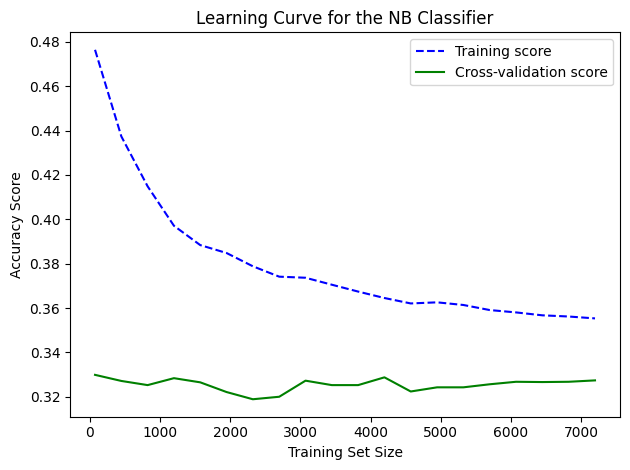

LR(acc): 0.330375 (0.010725)
LR(f1): 0.321546 (0.010954)


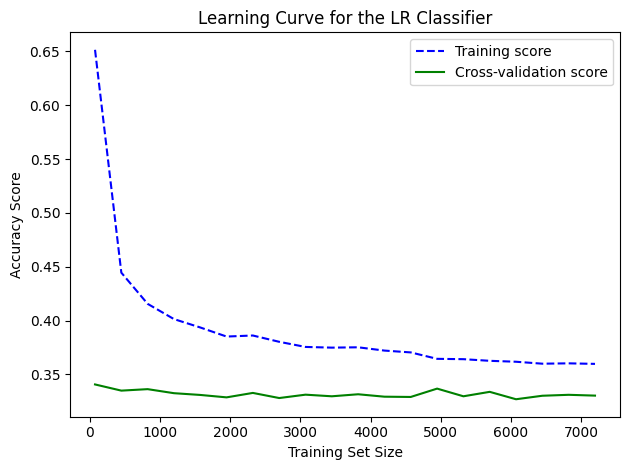

SVM(acc): 0.332875 (0.016432)
SVM(f1): 0.329761 (0.016998)


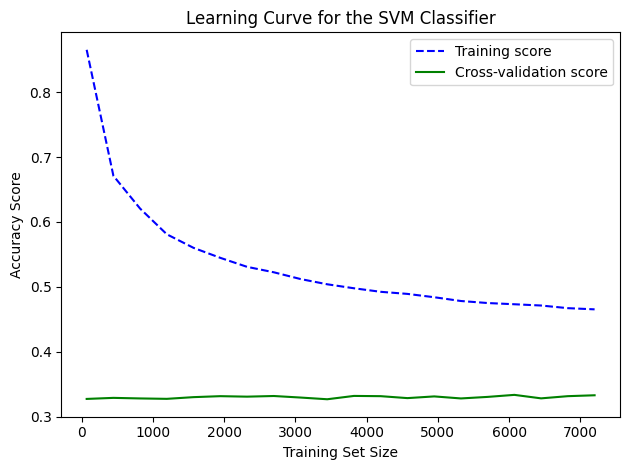

In [24]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer


models = []

models.append(('NB', GaussianNB()))
models.append(('LR', LogisticRegression()))
models.append(('SVM', SVC(gamma = 'auto')))

results = []
names = []

f1 = make_scorer(f1_score, average='weighted')

for name, model in models:
    kfold = KFold(n_splits = 10, random_state = 13, shuffle = True)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = 'accuracy')
    results.append(cv_results)
    names.append(name)
    msg = '%s(acc): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = f1)
    results.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(estimator = model,
                                                              X = X_train,
                                                              y = y_train,
                                                              train_sizes = np.linspace(0.01, 1.0, 20),
                                                              cv = kfold,
                                                              scoring = 'accuracy', shuffle = True)
    mean_training = np.mean(train_scores, axis=1)
    mean_testing = np.mean(validation_scores, axis=1)

    plt.plot(train_sizes, mean_training, '--', color = "b",  label = "Training score")
    plt.plot(train_sizes, mean_testing, color = "g", label = "Cross-validation score")
    plt.title(f"Learning Curve for the " + name + " Classifier")
    plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc = "best")
    plt.tight_layout()
    plt.show()


In [26]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model = SVC(gamma = 'auto')
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print(metrics.accuracy_score(predictions, y_test))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.328
[[291 215 206]
 [277 173 208]
 [281 157 192]]
              precision    recall  f1-score   support

           0       0.34      0.41      0.37       712
           1       0.32      0.26      0.29       658
           2       0.32      0.30      0.31       630

    accuracy                           0.33      2000
   macro avg       0.33      0.33      0.32      2000
weighted avg       0.33      0.33      0.33      2000

